In [ ]:
import os
import json
import geopandas as gpd
import requests

import io
import zipfile

import rasterio
from rasterio.shutil import copy as rio_copy
from rasterio.enums import Resampling

import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Utility functions
def get_bbox(geojson_path):
    """Extracts bounding box coordinates from an input vector data file"""
    gdf = gpd.read_file(geojson_path) # you can use a .shp file also here directly

    if gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs(4326)
    bbox = tuple([float(b) for b in gdf.total_bounds])

    return bbox

In [ ]:
#Exported the sentinel2 footprints from the QGIS file as geojson
geojson_path = './FireNearFlinFlonMay302025.geojson'
#geojson_path = './nwt_example.geojson'
aoi_gdf = gpd.read_file(geojson_path)
utm_crs = aoi_gdf.estimate_utm_crs().to_epsg()
bbox = get_bbox(geojson_path)
bbox

(-105.00030849106282,
 54.017541579537756,
 -100.37782753607877,
 55.94064592141688)

In [ ]:
# Filter assets by imaging date
start_date = '2025-06-03T00:00:00Z'
end_date = '2025-06-03T23:59:59Z'

In [ ]:
# Open EODMS STAC catalog and explore available collections
ogc_api_url = 'https://www.eodms-sgdot.nrcan-rncan.gc.ca/search/'
# Construct the collections endpoint
collections_url = f"{ogc_api_url}/collections"
# Send a GET request to the collections endpoint
response = requests.get(collections_url)
if response.status_code == 200:
    collections = response.json() 
    print("Collections available in the OGC API:")
    num_collections = len(collections.get("collections", []))
    print(f"Number of collections: {num_collections}")
    for collection in collections.get("collections", []):
        print(f"- {collection.get('id')}: {collection.get('title')}")
else:  
    print(f"Failed to retrieve collections. Status code: {response.status_code}")


Collections available in the OGC API:
Number of collections: 7
- EGS_Flood_Footprint_Active_en: Floods in Canada - Active - Satellite Footprints
- EGS_Flood_Extent_Archive_en: Floods in Canada - Archive - Product Extents
- EGS_Flood_Footprint_Archive_en: Floods in Canada - Archive - Satellite Footprints
- EGS_Flood_Extent_Current_en: Floods in Canada - Current Year - Product Extents
- EGS_Flood_Footprint_Current_en: Floods in Canada - Current Year - Satellite Footprints
- EGS_Flood_Footprint_Seasonal_en: Floods in Canada - Seasonal - Satellite Footprints
- sentinel2: Sentinel 2


In [ ]:
# List all items in sentinel 2 collection that intersect with area of interest within date range
collection_id = 'sentinel2'
datetime_range = f"{start_date}/{end_date}"

# Construct the search URL
search_url = f"{ogc_api_url}/collections/{collection_id}/items" #items.json for qgis
search_url

In [ ]:
# Set query parameters
# Observe that a limit has been set
params = {
    "datetime": datetime_range, #capital D for ms4w - Datetime
     "bbox":",".join(map(str, bbox)),
     "limit":100
}
params

{'datetime': '2025-06-03T00:00:00Z/2025-06-03T23:59:59Z',
 'bbox': '-105.00030849106282,54.017541579537756,-100.37782753607877,55.94064592141688',
 'limit': 100}

In [ ]:
# Make the request
response = requests.get(search_url, params=params)
desired_properties = ["producttype", "acquisition_start", "product_link"]
# Check and parse the response
if response.status_code == 200:
    features = response.json().get("features", [])
    print(f"Found {len(features)} features between {start_date} and {end_date}.")
    print("Product Type","       ", "Acquisition start","          ", "Product Link", )
    for feature in features[:100]:      
        properties = feature.get("properties", {})
        product_type = properties.get('producttype')
        acquisition_start = properties.get('acquisition_start')
        product_link = properties.get('product_link')
        print(product_type,"       ", acquisition_start,"          ", product_link)
else:
    print(f"Failed to retrieve features. Status code: {response.status_code}")

Found 21 features between 2025-06-03T00:00:00Z and 2025-06-03T23:59:59Z.
Product Type         Acquisition start            Product Link
S2MSI2A         2025-06-02T17:59:31.025Z            https://sentinel-products-ca-mirror.s3.ca-central-1.amazonaws.com/Sentinel-2/S2MSI2A/2025/06/02/S2C_MSIL2A_20250602T175931_N0511_R041_T14UMF_20250602T225512.zip
S2MSI2A         2025-06-02T17:59:31.025Z            https://sentinel-products-ca-mirror.s3.ca-central-1.amazonaws.com/Sentinel-2/S2MSI2A/2025/06/02/S2C_MSIL2A_20250602T175931_N0511_R041_T13UDV_20250602T225512.zip
S2MSI2A         2025-06-02T17:59:31.025Z            https://sentinel-products-ca-mirror.s3.ca-central-1.amazonaws.com/Sentinel-2/S2MSI2A/2025/06/02/S2C_MSIL2A_20250602T175931_N0511_R041_T13VFC_20250602T225512.zip
S2MSI2A         2025-06-02T17:59:31.025Z            https://sentinel-products-ca-mirror.s3.ca-central-1.amazonaws.com/Sentinel-2/S2MSI2A/2025/06/02/S2C_MSIL2A_20250602T175931_N0511_R041_T13VEC_20250602T225512.zip
S2MSI2A     

In [ ]:
# Download and extract a sentinel 2 SAFE zip
if not os.path.exists('./sentinel_2_data'):
    os.mkdir('./sentinel_2_data')
# Directory to extract files to
extract_to = "./sentinel_2_data"

# Create the directory if it doesn't exist
os.makedirs(extract_to, exist_ok=True)
# Extract all files

#Using one of the results for the perfect demo
product_link = "https://sentinel-products-ca-mirror.s3.ca-central-1.amazonaws.com/Sentinel-2/S2MSI2A/2025/06/02/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.zip"

zip_url = product_link
zip_name = os.path.splitext(os.path.basename(zip_url))[0]
# Download and extract
response = requests.get(zip_url)
if response.status_code == 200:
    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(extract_to)

    print(f"Files extracted to '{extract_to}' '{zip_name}'")
else:
    print(f"Failed to download ZIP file. Status code: {response.status_code}")





Files extracted to './sentinel_2_data' 'S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512'


In [ ]:
def find_img_data_dir(start_path):
    for root, dirs, files in os.walk(start_path):
        if "IMG_DATA" in dirs:
            return os.path.join(root, "IMG_DATA")
    return None


In [ ]:
# Example usage:
start_directory = extract_to + "/" + zip_name + ".SAFE"
print ("directory is " + start_directory)
img_data_path = find_img_data_dir(start_directory)

if img_data_path:
    print(f"'img_data' directory found at: {img_data_path}")
else:
    print("No 'img_data' directory found.")

directory is ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE
'img_data' directory found at: ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE\GRANULE\L2A_T13UFA_A003872_20250602T180304\IMG_DATA


In [ ]:
def find_file_by_band_name(search_dir, band_to_search):
    for root, dirs, files in os.walk(search_dir):
        for file in files:
            if band_to_search in file:
                #return os.path.join(root, file)
                return root, file
    return None


In [ ]:
def find_band_jp2file_make_cog(directory_to_search, band_to_search):
    band_file_dir, found_file = find_file_by_band_name(directory_to_search, band_to_search)
    band_filename = os.path.splitext(os.path.basename(found_file))[0]
    if found_file:
        print(f"File found: {found_file}")
        print(f"Base name of file: {band_filename}")
        print(f"Directory of file: {band_file_dir}")
    else:
        print("No matching file found.")
     # Input JP2 file path
    input_jp2 = band_file_dir + "/" + band_filename + ".jp2"

    # Output COG file path
    output_cog = band_file_dir + "/" + band_filename + "_cog.tif"

    # Define COG profile
    cog_profile = {
        'driver': 'COG',
        'compress': 'deflate',
        'blocksize': 512,
        'overview_resampling': Resampling.nearest
    }

    # Convert JP2 to COG
    rio_copy(input_jp2, output_cog,  **cog_profile)

    print(f"Converted {input_jp2} to Cloud Optimized GeoTIFF: {output_cog}")
    return output_cog

In [ ]:
band_to_search = "_B12"
B12_cog = find_band_jp2file_make_cog(img_data_path, band_to_search)

File found: T13UFA_20250602T175931_B12_20m.jp2
Base name of file: T13UFA_20250602T175931_B12_20m
Directory of file: ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE\GRANULE\L2A_T13UFA_A003872_20250602T180304\IMG_DATA\R20m
Converted ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE\GRANULE\L2A_T13UFA_A003872_20250602T180304\IMG_DATA\R20m/T13UFA_20250602T175931_B12_20m.jp2 to Cloud Optimized GeoTIFF: ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE\GRANULE\L2A_T13UFA_A003872_20250602T180304\IMG_DATA\R20m/T13UFA_20250602T175931_B12_20m_cog.tif


In [ ]:
band_to_search = "_B8A"
B8A_cog = find_band_jp2file_make_cog(img_data_path, band_to_search)

File found: T13UFA_20250602T175931_B8A_20m.jp2
Base name of file: T13UFA_20250602T175931_B8A_20m
Directory of file: ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE\GRANULE\L2A_T13UFA_A003872_20250602T180304\IMG_DATA\R20m
Converted ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE\GRANULE\L2A_T13UFA_A003872_20250602T180304\IMG_DATA\R20m/T13UFA_20250602T175931_B8A_20m.jp2 to Cloud Optimized GeoTIFF: ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE\GRANULE\L2A_T13UFA_A003872_20250602T180304\IMG_DATA\R20m/T13UFA_20250602T175931_B8A_20m_cog.tif


In [ ]:
#B04 is found both in 10m resolution and 20m resolution
#we need to get all bands in same resolution so use the one at 20m resolution
img_data_path = img_data_path + "/R20m"

In [ ]:
band_to_search = "_B04"
B04_cog = find_band_jp2file_make_cog(img_data_path, band_to_search)

File found: T13UFA_20250602T175931_B04_20m.jp2
Base name of file: T13UFA_20250602T175931_B04_20m
Directory of file: ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE\GRANULE\L2A_T13UFA_A003872_20250602T180304\IMG_DATA/R20m
Converted ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE\GRANULE\L2A_T13UFA_A003872_20250602T180304\IMG_DATA/R20m/T13UFA_20250602T175931_B04_20m.jp2 to Cloud Optimized GeoTIFF: ./sentinel_2_data/S2C_MSIL2A_20250602T175931_N0511_R041_T13UFA_20250602T225512.SAFE\GRANULE\L2A_T13UFA_A003872_20250602T180304\IMG_DATA/R20m/T13UFA_20250602T175931_B04_20m_cog.tif


In [ ]:
# Load each band from its respective COG file
with rasterio.open(B12_cog) as red_src:
    red = red_src.read(1)

with rasterio.open(B8A_cog) as green_src:
    green = green_src.read(1)

with rasterio.open(B04_cog) as blue_src:
    blue = blue_src.read(1)

# Stack into RGB format
rgb = np.stack([red, green, blue], axis=-1)


In [ ]:
def plot_RGB_cog(rgb):
    # Normalize to [0, 1] for display
    rgb_normalized = rgb.astype(np.float32)
    rgb_normalized /= rgb_normalized.max()

    # Plot using matplotlib
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_normalized)
    plt.title("RGB Composite")
    plt.axis('off')
    plt.show()


In [ ]:
def plot_band_cog(band_cog_file):
    # Path to your COG file
    cog_path = band_cog_file

    # Open and read the first band
    with rasterio.open(cog_path) as src:
        band1 = src.read(1)

    # Plot the band
    plt.figure(figsize=(10, 8))
    plt.imshow(band1, cmap='gray')
    #aoi_gdf.to_crs(utm_crs).plot(ax=axes[0], facecolor='none', edgecolor='brown', linewidth=2)
    plt.colorbar(label='Pixel values')
    plt.title('Single Band Visualization of COG')
    plt.xlabel('Column Index')
    plt.ylabel('Row Index')
    plt.show()


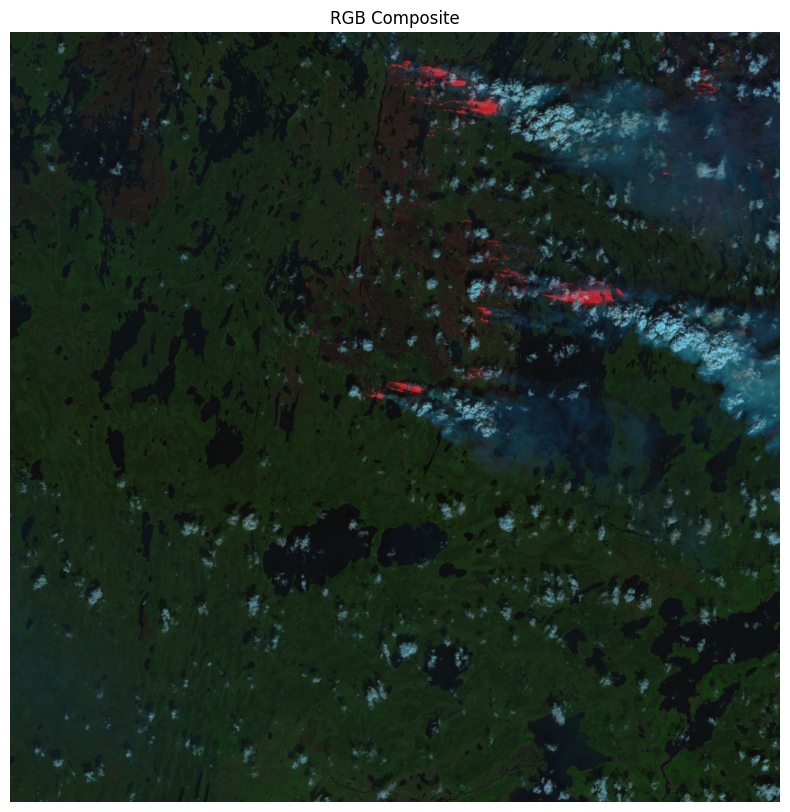

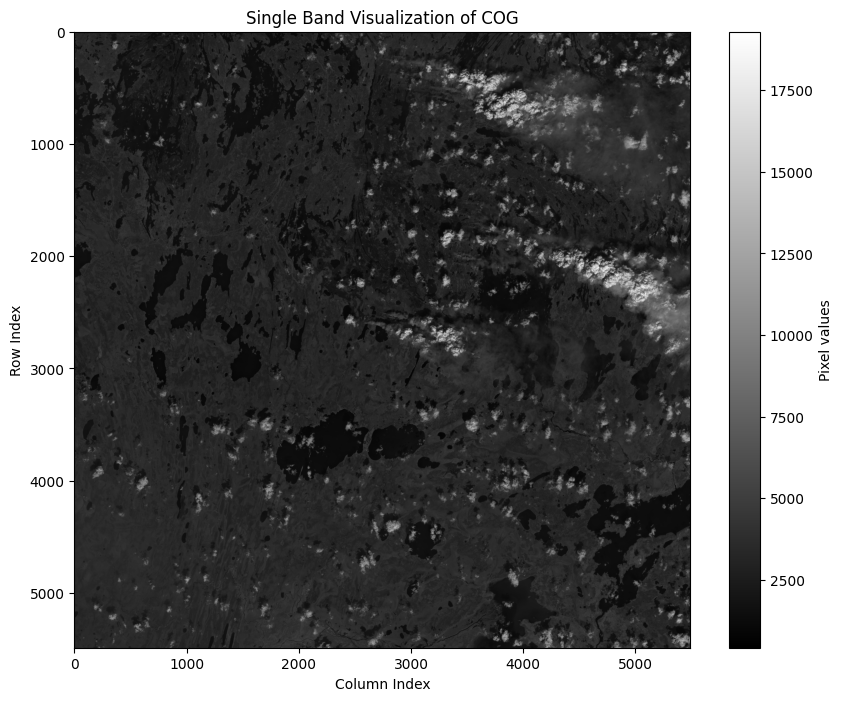

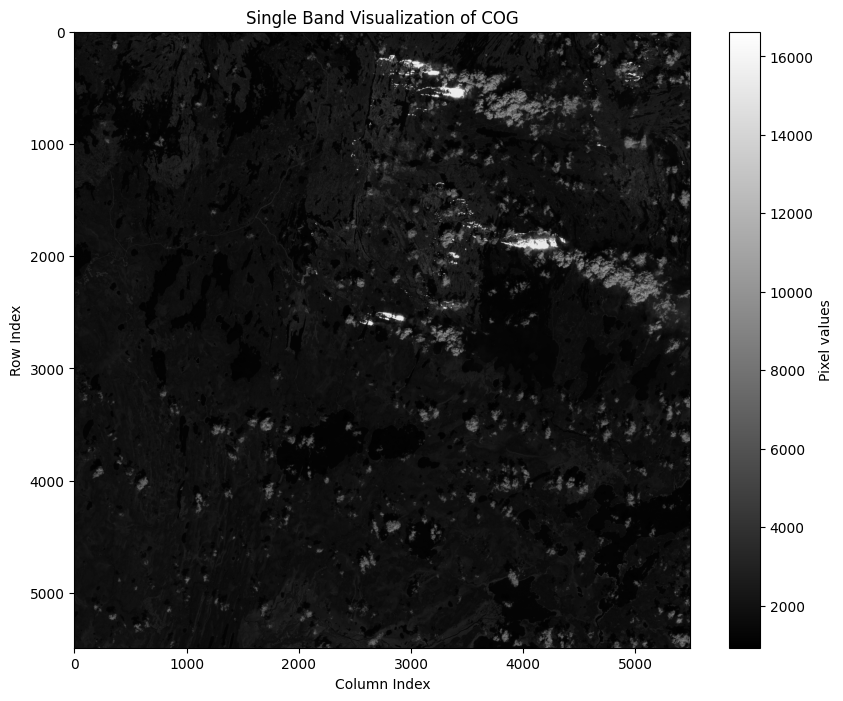

In [ ]:
plot_RGB_cog(rgb)
plot_band_cog(B8A_cog) # NIR
plot_band_cog(B12_cog) # SWIR